In [3]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import pyodbc 

conn = pyodbc.connect('Driver={ODBC Driver 17 For SQL Server};'
                      'Server=localhost\SQLEXPRESS;'
                      'Database=E_commerce_Sales;'
                      'Trusted_Connection=Yes;'
                      'Mars_Connection=Yes;')
cursor = conn.cursor()
cursor.execute("Select * From e_commerce_clean")

df = pd.read_sql("Select * From e_commerce_clean", conn)
df

C:\Users\devia\AppData\Local\Temp\ipykernel_15416\2608383544.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("Select * From e_commerce_clean", conn)


,order_id,customer_id,order_purchase_timestamp,order_delivered_customer_date,product_id,price,payment_value,payment_type,review_score,delivery_Days,order_Month
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,2017-09-13 08:59:02,2017-09-20 23:43:48,4244733e06e7ecb4970a6e2683c13e61,58.900002,72.190002,credit_card,5,7.0,2017-09
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,2017-04-26 10:53:06,2017-05-12 16:04:24,e5f2d52b802189ee658865ca93d83a8f,239.899994,259.829987,credit_card,4,16.0,2017-04
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,2018-01-14 14:33:31,2018-01-22 13:19:16,c777355d18b72b67abbeef9df44fd0fd,199.000000,216.869995,credit_card,5,8.0,2018-01
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,2018-08-08 10:00:35,2018-08-14 13:32:39,7634da152a4610f1595efa32f14722fc,12.990000,25.780001,credit_card,4,6.0,2018-08
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,2017-02-04 13:57:51,2017-03-01 16:42:31,ac6c3623068f30de03045865e4e10089,199.899994,218.039993,credit_card,5,25.0,2017-02
...,...,...,...,...,...,...,...,...,...,...,...
118302,fffc94f6ce00a00581880bf54a75a037,b51593916b4b8e0d6f66f2ae24f2673d,2018-04-23 13:57:06,2018-05-10 22:56:40,4aa6014eceb682077f9dc4bffebc05b0,299.989990,343.399994,boleto,5,17.0,2018-04
118303,fffcd46ef2263f404302a634eb57f7eb,84c5d4fbaf120aae381fad077416eaa0,2018-07-14 10:26:46,2018-07-23 20:31:55,32e07fd915822b0765e448c4dd74c828,350.000000,386.529999,boleto,5,9.0,2018-07
118304,fffce4705a9662cd70adb13d4a31832d,29309aa813182aaddc9b259e31b870e6,2017-10-23 17:07:56,2017-10-28 12:22:22,72a30483855e2eafc67aee5dc2560482,99.900002,116.849998,credit_card,5,5.0,2017-10
118305,fffe18544ffabc95dfada21779c9644f,b5e6afd5a41800fdf401e0272ca74655,2017-08-14 23:02:59,2017-08-16 21:59:40,9c422a519119dcad7575db5af1ba540e,55.990002,64.709999,credit_card,5,2.0,2017-08


In [4]:
#check null and duplicates valye
df.isnull().sum(), #((978 customers didn't write the review)
df.duplicated().sum() #(delivery_days and customer_date  have multiple same values its will be fine.) 

#Date 
df["order_Month"] = pd.to_datetime(df["order_Month"])
df["Year"]= df["order_Month"].dt.year
df["Month"]= df["order_Month"].dt.month
df

,order_id,customer_id,order_purchase_timestamp,order_delivered_customer_date,product_id,price,payment_value,payment_type,review_score,delivery_Days,order_Month,Year,Month
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,2017-09-13 08:59:02,2017-09-20 23:43:48,4244733e06e7ecb4970a6e2683c13e61,58.900002,72.190002,credit_card,5,7.0,2017-09-01,2017,9
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,2017-04-26 10:53:06,2017-05-12 16:04:24,e5f2d52b802189ee658865ca93d83a8f,239.899994,259.829987,credit_card,4,16.0,2017-04-01,2017,4
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,2018-01-14 14:33:31,2018-01-22 13:19:16,c777355d18b72b67abbeef9df44fd0fd,199.000000,216.869995,credit_card,5,8.0,2018-01-01,2018,1
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,2018-08-08 10:00:35,2018-08-14 13:32:39,7634da152a4610f1595efa32f14722fc,12.990000,25.780001,credit_card,4,6.0,2018-08-01,2018,8
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,2017-02-04 13:57:51,2017-03-01 16:42:31,ac6c3623068f30de03045865e4e10089,199.899994,218.039993,credit_card,5,25.0,2017-02-01,2017,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
118302,fffc94f6ce00a00581880bf54a75a037,b51593916b4b8e0d6f66f2ae24f2673d,2018-04-23 13:57:06,2018-05-10 22:56:40,4aa6014eceb682077f9dc4bffebc05b0,299.989990,343.399994,boleto,5,17.0,2018-04-01,2018,4
118303,fffcd46ef2263f404302a634eb57f7eb,84c5d4fbaf120aae381fad077416eaa0,2018-07-14 10:26:46,2018-07-23 20:31:55,32e07fd915822b0765e448c4dd74c828,350.000000,386.529999,boleto,5,9.0,2018-07-01,2018,7
118304,fffce4705a9662cd70adb13d4a31832d,29309aa813182aaddc9b259e31b870e6,2017-10-23 17:07:56,2017-10-28 12:22:22,72a30483855e2eafc67aee5dc2560482,99.900002,116.849998,credit_card,5,5.0,2017-10-01,2017,10
118305,fffe18544ffabc95dfada21779c9644f,b5e6afd5a41800fdf401e0272ca74655,2017-08-14 23:02:59,2017-08-16 21:59:40,9c422a519119dcad7575db5af1ba540e,55.990002,64.709999,credit_card,5,2.0,2017-08-01,2017,8


<function matplotlib.pyplot.show(close=None, block=None)>

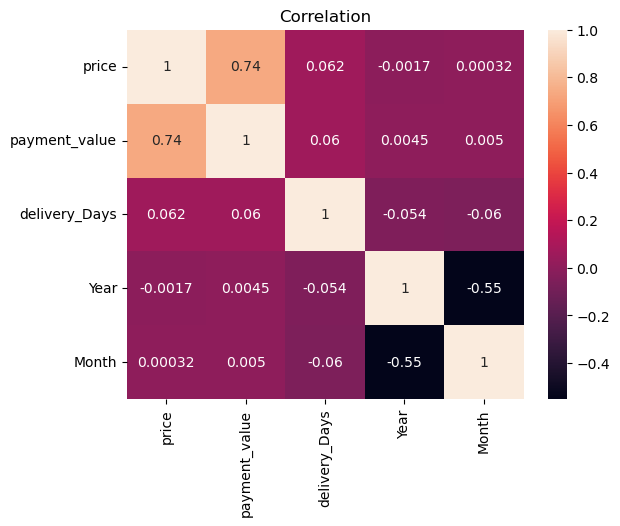

In [5]:
corr = df.corr(numeric_only = True)
sns.heatmap(corr, annot =True,linecolor='red')
plt.title("Correlation")
plt.show

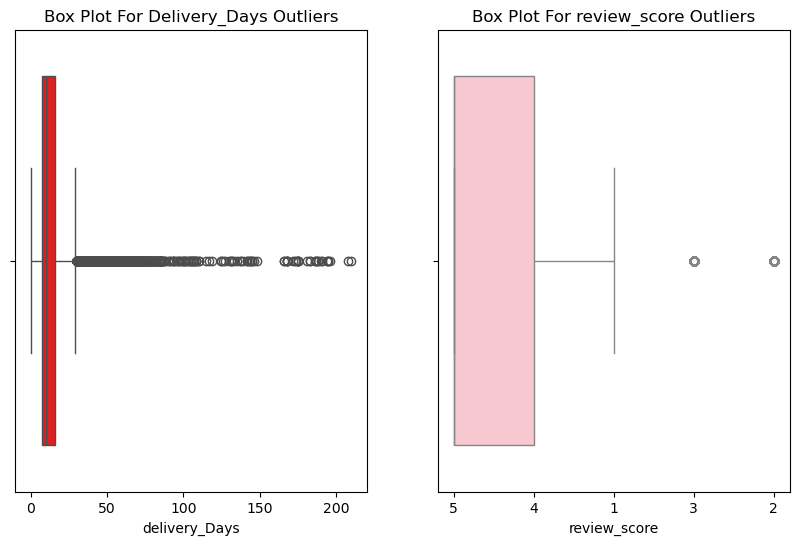

In [6]:
#for outlier detection 
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
sns.boxplot(data = df, x = "delivery_Days", color= 'red')
plt.title("Box Plot For Delivery_Days Outliers")
plt.subplot(1,2,2)
sns.boxplot(data = df, x = "review_score", color='pink')
plt.title("Box Plot For review_score Outliers")
plt.show()

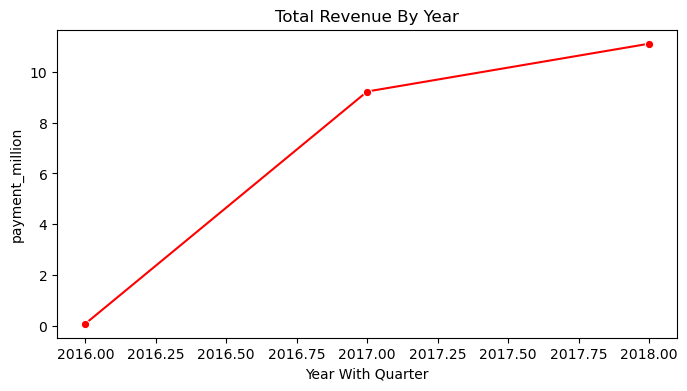

In [21]:
#Trend plots 
TotalRevenueByMonth = df.groupby("Year")["payment_value"].sum().reset_index()
TotalRevenueByMonth['payment_million'] = TotalRevenueByMonth['payment_value']/1000000
plt.figure(figsize=(8,4))
sns.lineplot(data = TotalRevenueByMonth, x = "Year", y = "payment_million", marker = "o", color="red")
plt.xlabel("Year With Quarter")
plt.title("Total Revenue By Year")
plt.show()

    